In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import regionmask
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cmocean

from unseen import fileio

import utils

In [2]:
infile = '/g/data/xv83/unseen-projects/outputs/bias/data/rx1day_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
ds = fileio.open_dataset(infile)
overlap_threshold = 0.67
shape_gpd = gpd.read_file('/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp')
shape_rgm = regionmask.from_geopandas(
    shape_gpd,
    names="AUS_NAME21",
    abbrevs="AUS_CODE21",
    name="australia"
)
frac = shape_rgm.mask_3D_frac_approx(ds)
mask = frac.sel(region=0) >= overlap_threshold

In [3]:
return_period = 1000
infile = 'rx1day_spatial.nc'
ds_rx1day = xr.open_dataset(infile)

In [4]:
return_period = 1000
infile = 'txx_spatial.nc'
ds_txx = xr.open_dataset(infile)

## nModels

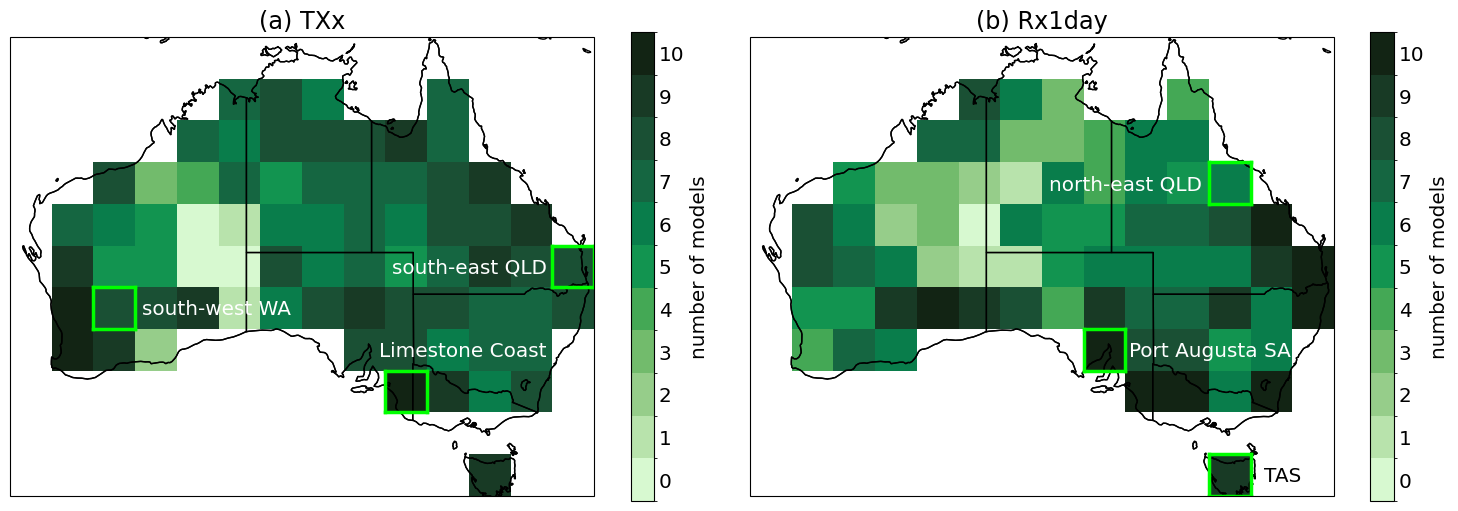

In [5]:
fig = plt.figure(figsize=[15, 5])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = ds_txx['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('(a) TXx')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
#ax1.annotate('test', xy=(2, 1), xytext=(3, 1.5), arrowprops=dict(facecolor='black', shrink=0.05), transform=ccrs.PlateCarree())

ax1.text(
    utils.lon_array[13] - 13,
    utils.lat_array[5] - 0.5,
    'south-east QLD',
    fontsize='x-large',
    color='white',
    transform=ccrs.PlateCarree()
)
ax1.text(
    utils.lon_array[9] - 2,
    utils.lat_array[2] + 2.5 ,
    'Limestone Coast',
    fontsize='x-large',
    color='white',
    transform=ccrs.PlateCarree()
)
ax1.text(
    utils.lon_array[2] + 2,
    utils.lat_array[4] - 0.5,
    'south-west WA',
    fontsize='x-large',
    color='white',
    transform=ccrs.PlateCarree()
)

cbar1 = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar1.ax.tick_params(size=0)

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 9, color='lime')
utils.highlight_grid_box(ax1, 4, 2, color='lime')

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = ds_rx1day['nmodels'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax2.set_title('(b) Rx1day')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax2.text(
    utils.lon_array[11] + 2.5,
    utils.lat_array[0] - 0.5,
    'TAS',
    fontsize='x-large',
    color='black',
    transform=ccrs.PlateCarree()
)
ax2.text(
    utils.lon_array[11] - 13,
    utils.lat_array[7] - 0.5,
    'north-east QLD',
    fontsize='x-large',
    color='white',
    transform=ccrs.PlateCarree()
)
ax2.text(
    utils.lon_array[8] + 1.75,
    utils.lat_array[3] - 0.5,
    'Port Augusta SA',
    fontsize='x-large',
    color='white',
    transform=ccrs.PlateCarree()
)

cbar2 = fig.colorbar(im2, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar2.ax.tick_params(size=0)

utils.highlight_grid_box(ax2, 0, 11, color='lime')
utils.highlight_grid_box(ax2, 7, 11, color='lime')
utils.highlight_grid_box(ax2, 3, 8, color='lime')

plt.tight_layout()
plt.savefig('figures/nmodels_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

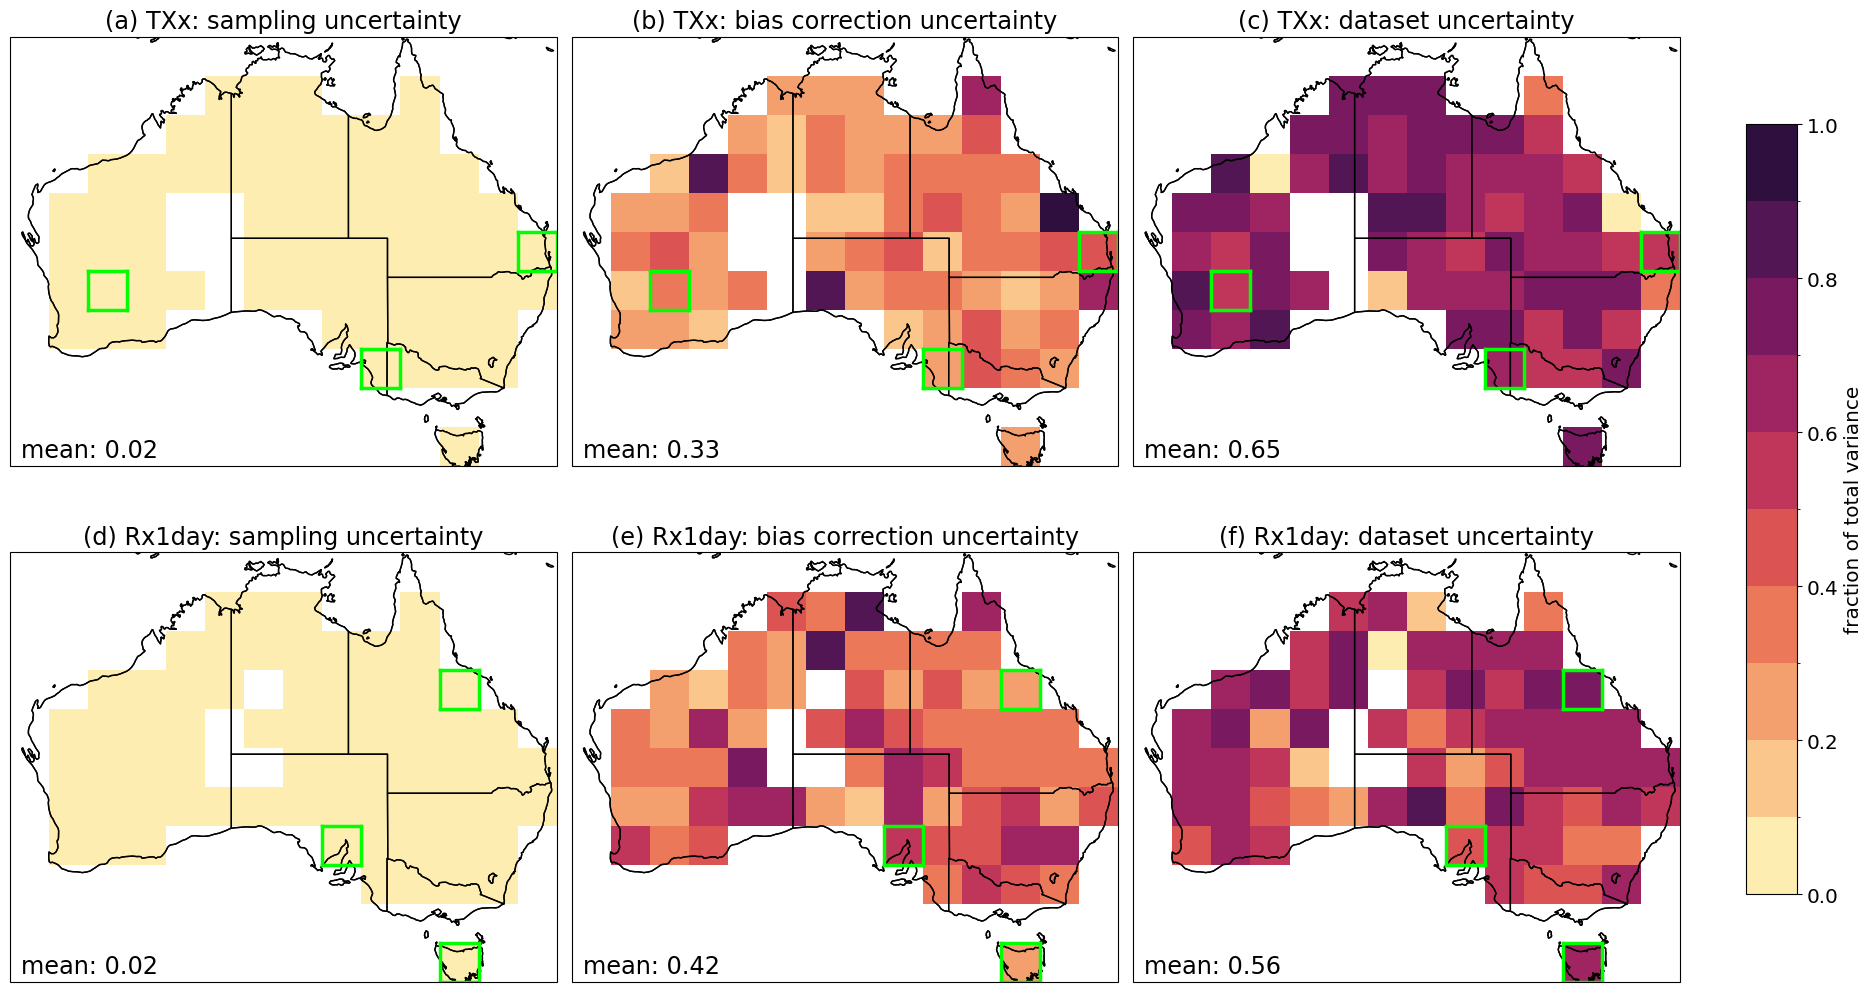

In [6]:
fig = plt.figure(figsize=[17, 11])
cbar_levels = np.arange(0, 1.01, 0.1)
cmap = cmocean.cm.matter

ax1 = fig.add_subplot(231, projection=ccrs.PlateCarree())
g_frac_txx = ds_txx.sel({'lev': return_period})['G2'] / ds_txx.sel({'lev': return_period})['T2'] 
im1 = g_frac_txx.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('(a) TXx: sampling uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
g_mean_txx = float(g_frac_txx.mean())
ax1.text(0.02, 0.02, f'mean: {g_mean_txx:.2f}', transform=ax1.transAxes, fontsize='xx-large')

ax2 = fig.add_subplot(232, projection=ccrs.PlateCarree())
b_frac_txx = ds_txx.sel({'lev': return_period})['B2'] / ds_txx.sel({'lev': return_period})['T2']
im2 = b_frac_txx.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('(b) TXx: bias correction uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
b_mean_txx = float(b_frac_txx.mean())
ax2.text(0.02, 0.02, f'mean: {b_mean_txx:.2f}', transform=ax2.transAxes, fontsize='xx-large')

ax3 = fig.add_subplot(233, projection=ccrs.PlateCarree())
m_frac_txx = ds_txx.sel({'lev': return_period})['M2'] / ds_txx.sel({'lev': return_period})['T2']
im3 = m_frac_txx.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('(c) TXx: dataset uncertainty')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
m_mean_txx = float(m_frac_txx.mean())
ax3.text(0.02, 0.02, f'mean: {m_mean_txx:.2f}', transform=ax3.transAxes, fontsize='xx-large')

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='fraction of total variance')

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 9, color='lime')
utils.highlight_grid_box(ax1, 4, 2, color='lime')
utils.highlight_grid_box(ax2, 5, 13, color='lime')
utils.highlight_grid_box(ax2, 2, 9, color='lime')
utils.highlight_grid_box(ax2, 4, 2, color='lime')
utils.highlight_grid_box(ax3, 5, 13, color='lime')
utils.highlight_grid_box(ax3, 2, 9, color='lime')
utils.highlight_grid_box(ax3, 4, 2, color='lime')


ax4 = fig.add_subplot(234, projection=ccrs.PlateCarree())
g_frac_rx1day = ds_rx1day.sel({'lev': return_period})['G2'] / ds_rx1day.sel({'lev': return_period})['T2']
im4 = g_frac_rx1day.plot(
    ax=ax4,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax4.set_title('(d) Rx1day: sampling uncertainty')
ax4.coastlines()
ax4.add_feature(cartopy.feature.STATES)
g_mean_rx1day = float(g_frac_rx1day.mean())
ax4.text(0.02, 0.02, f'mean: {g_mean_rx1day:.2f}', transform=ax4.transAxes, fontsize='xx-large')

ax5 = fig.add_subplot(235, projection=ccrs.PlateCarree())
b_frac_rx1day = ds_rx1day.sel({'lev': return_period})['B2'] / ds_rx1day.sel({'lev': return_period})['T2']
im5 = b_frac_rx1day.plot(
    ax=ax5,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax5.set_title('(e) Rx1day: bias correction uncertainty')
ax5.coastlines()
ax5.add_feature(cartopy.feature.STATES)
b_mean_rx1day = float(b_frac_rx1day.mean())
ax5.text(0.02, 0.02, f'mean: {b_mean_rx1day:.2f}', transform=ax5.transAxes, fontsize='xx-large')

ax6 = fig.add_subplot(236, projection=ccrs.PlateCarree())
m_frac_rx1day = ds_rx1day.sel({'lev': return_period})['M2'] / ds_rx1day.sel({'lev': return_period})['T2']
im6 = m_frac_rx1day.plot(
    ax=ax6,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax6.set_title('(f) Rx1day: dataset uncertainty')
ax6.coastlines()
ax6.add_feature(cartopy.feature.STATES)
m_mean_rx1day = float(m_frac_rx1day.mean())
ax6.text(0.02, 0.02, f'mean: {m_mean_rx1day:.2f}', transform=ax6.transAxes, fontsize='xx-large')

utils.highlight_grid_box(ax4, 0, 11, color='lime')
utils.highlight_grid_box(ax4, 7, 11, color='lime')
utils.highlight_grid_box(ax4, 3, 8, color='lime')
utils.highlight_grid_box(ax5, 0, 11, color='lime')
utils.highlight_grid_box(ax5, 7, 11, color='lime')
utils.highlight_grid_box(ax5, 3, 8, color='lime')
utils.highlight_grid_box(ax6, 0, 11, color='lime')
utils.highlight_grid_box(ax6, 7, 11, color='lime')
utils.highlight_grid_box(ax6, 3, 8, color='lime')

#cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
#fig.colorbar(im4, cax=cbar_ax, label='fraction of total variance')

plt.tight_layout()
plt.savefig('figures/component_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

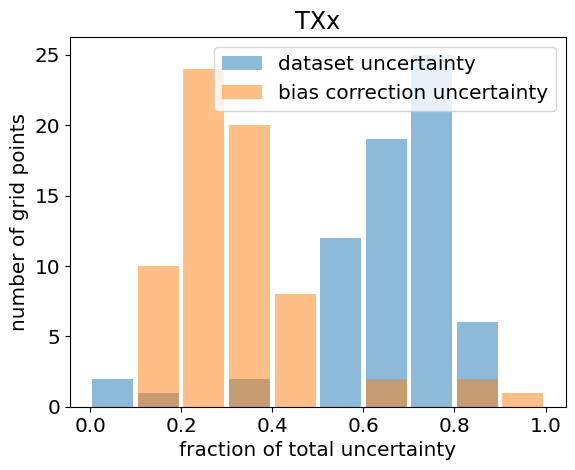

In [18]:
m_frac_txx_array = m_frac_txx.values.flatten()
m_frac_txx_array = m_frac_txx_array[~np.isnan(m_frac_txx_array)]

b_frac_txx_array = b_frac_txx.values.flatten()
b_frac_txx_array = b_frac_txx_array[~np.isnan(b_frac_txx_array)]

bins = np.arange(0, 1.01, 0.1)
plt.hist(m_frac_txx_array, bins=bins, density=False, rwidth=0.9, label='dataset uncertainty', color='tab:blue', alpha=0.5)
plt.hist(b_frac_txx_array, bins=bins, density=False, rwidth=0.9, label='bias correction uncertainty', color='tab:orange', alpha=0.5)
plt.xlabel('fraction of total uncertainty')
plt.ylabel('number of grid points')
plt.title('TXx')
#plt.xlim(0, 8.5)
plt.legend()
plt.show()

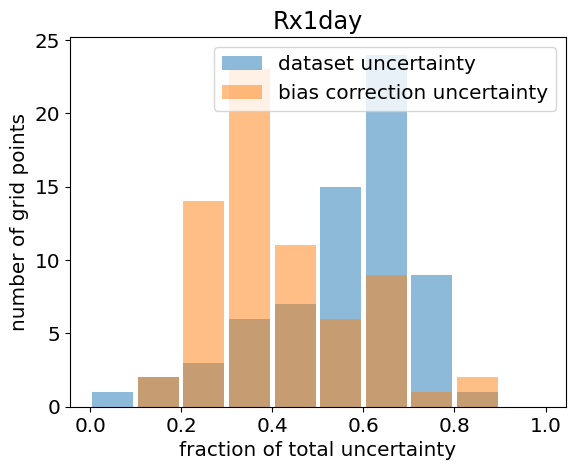

In [19]:
m_frac_rx1day_array = m_frac_rx1day.values.flatten()
m_frac_rx1day_array = m_frac_rx1day_array[~np.isnan(m_frac_rx1day_array)]

b_frac_rx1day_array = b_frac_rx1day.values.flatten()
b_frac_rx1day_array = b_frac_rx1day_array[~np.isnan(b_frac_rx1day_array)]

bins = np.arange(0, 1.01, 0.1)
plt.hist(m_frac_rx1day_array, bins=bins, density=False, rwidth=0.9, label='dataset uncertainty', color='tab:blue', alpha=0.5)
plt.hist(b_frac_rx1day_array, bins=bins, density=False, rwidth=0.9, label='bias correction uncertainty', color='tab:orange', alpha=0.5)
plt.xlabel('fraction of total uncertainty')
plt.ylabel('number of grid points')
plt.title('Rx1day')
#plt.xlim(0, 8.5)
plt.legend()
plt.show()

In [7]:
ratio_txx = ds_txx.sel({'lev': return_period})['T2'] / ds_txx.sel({'lev': return_period})['OG2']

In [8]:
ratio_rx1day = ds_rx1day.sel({'lev': return_period})['T2'] / ds_rx1day.sel({'lev': return_period})['OG2']

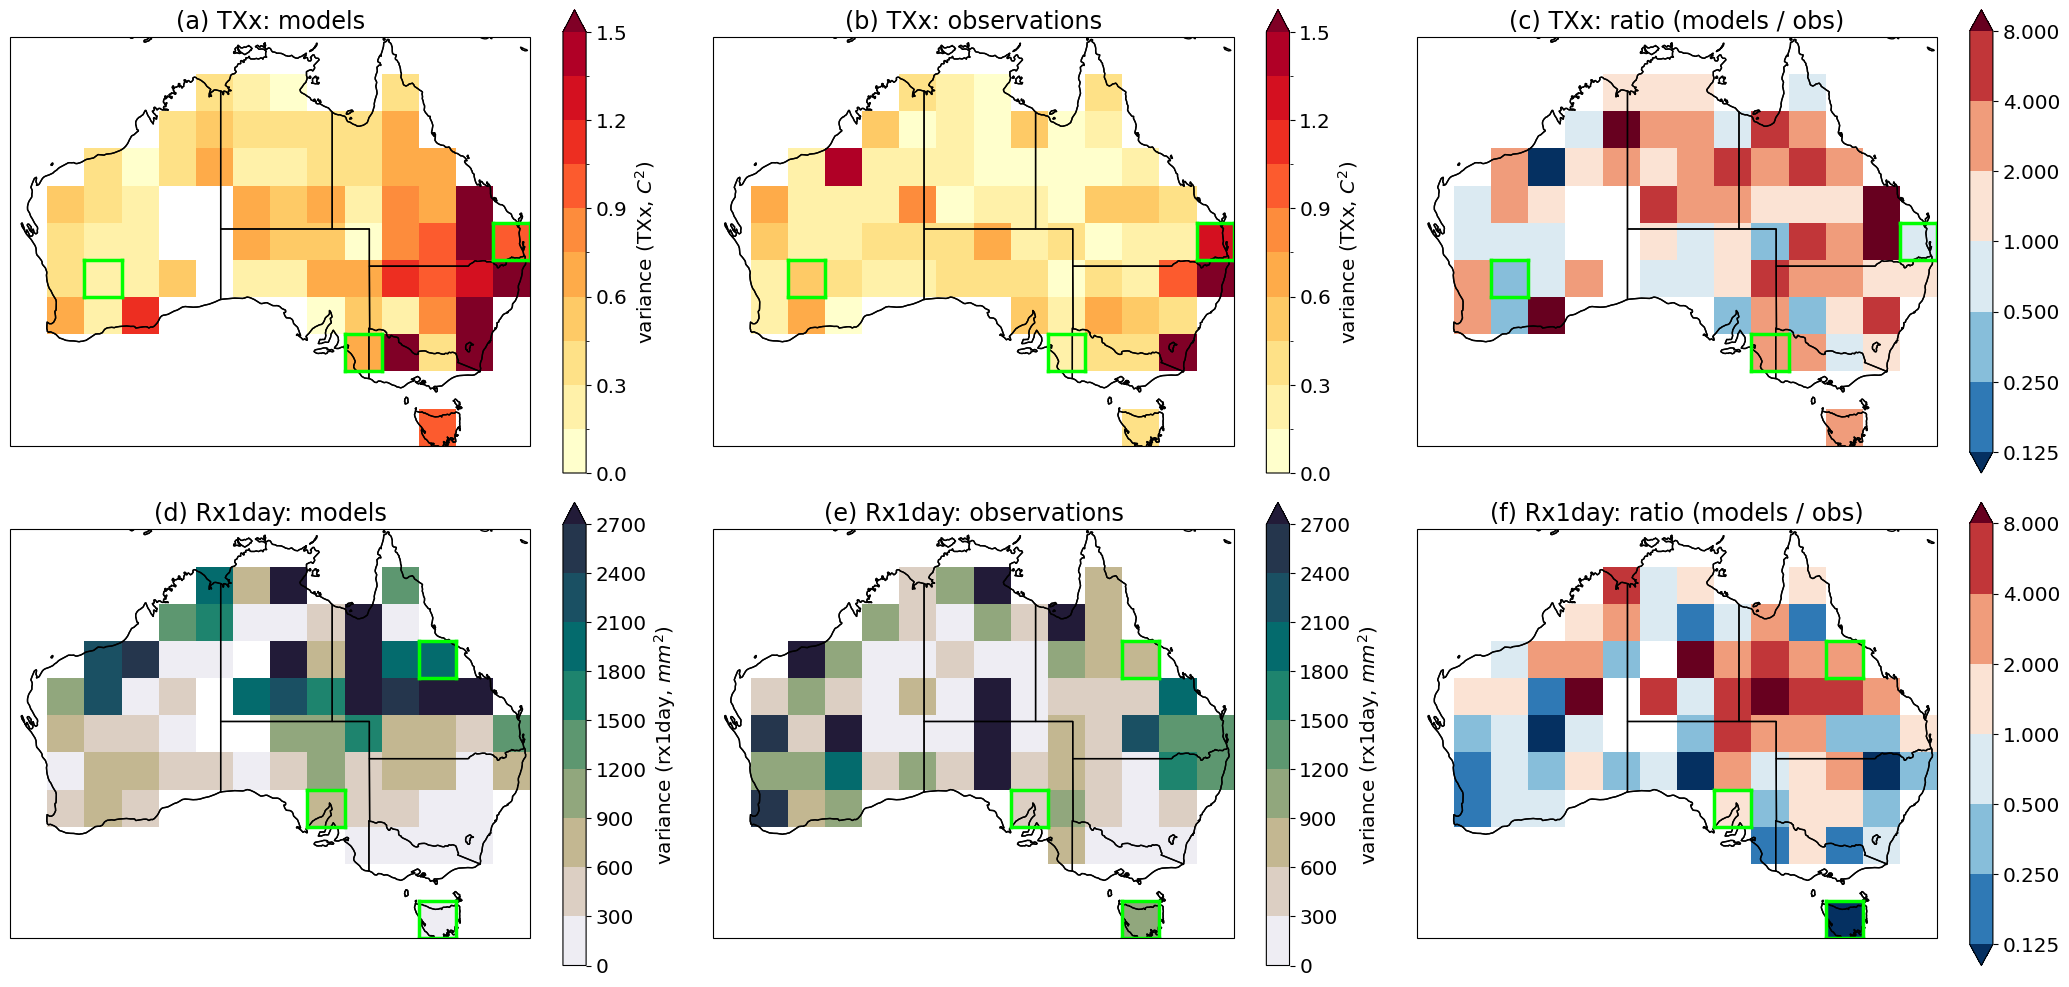

In [20]:
fig = plt.figure(figsize=[21, 10])

# TXx

ax1 = fig.add_subplot(231, projection=ccrs.PlateCarree())
im1 = ds_txx.sel({'lev': return_period})['T2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax1.set_title('(a) TXx: models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(232, projection=ccrs.PlateCarree())
im2 = ds_txx.sel({'lev': return_period})['OG2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax2.set_title('(b) TXx: observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(233, projection=ccrs.PlateCarree())
im3 = ratio_txx.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) TXx: ratio (models / obs)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 9, color='lime')
utils.highlight_grid_box(ax1, 4, 2, color='lime')
utils.highlight_grid_box(ax2, 5, 13, color='lime')
utils.highlight_grid_box(ax2, 2, 9, color='lime')
utils.highlight_grid_box(ax2, 4, 2, color='lime')
utils.highlight_grid_box(ax3, 5, 13, color='lime')
utils.highlight_grid_box(ax3, 2, 9, color='lime')
utils.highlight_grid_box(ax3, 4, 2, color='lime')

# Rx1day

ax4 = fig.add_subplot(234, projection=ccrs.PlateCarree())
im4 = ds_rx1day.sel({'lev': return_period})['T2'].plot(
    ax=ax4,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 3000, 300),
    extend='max',
    cmap=cmocean.cm.rain,
)
ax4.set_title('(d) Rx1day: models')
ax4.coastlines()
ax4.add_feature(cartopy.feature.STATES)

ax5 = fig.add_subplot(235, projection=ccrs.PlateCarree())
im5 = ds_rx1day.sel({'lev': return_period})['OG2'].plot(
    ax=ax5,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 3000, 300),
    extend='max',
    cmap=cmocean.cm.rain,
)
ax5.set_title('(e) Rx1day: observations')
ax5.coastlines()
ax5.add_feature(cartopy.feature.STATES)
obs_mean = float(ds_rx1day.sel({'lev': return_period})['OT2'].mean())

ax6 = fig.add_subplot(236, projection=ccrs.PlateCarree())
im6 = ratio_rx1day.plot(
    ax=ax6,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax6.set_title('(f) Rx1day: ratio (models / obs)')
ax6.coastlines()
ax6.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax4, 0, 11, color='lime')
utils.highlight_grid_box(ax4, 7, 11, color='lime')
utils.highlight_grid_box(ax4, 3, 8, color='lime')
utils.highlight_grid_box(ax5, 0, 11, color='lime')
utils.highlight_grid_box(ax5, 7, 11, color='lime')
utils.highlight_grid_box(ax5, 3, 8, color='lime')
utils.highlight_grid_box(ax6, 0, 11, color='lime')
utils.highlight_grid_box(ax6, 7, 11, color='lime')
utils.highlight_grid_box(ax6, 3, 8, color='lime')

plt.tight_layout()
plt.savefig('figures/total_uncertainty_maps.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()